# kNN & Decision Tree: Replicating Li, Wang & Wu (Wi-Fi Fingerprint Floor Classification)

This notebook reproduces the **kNN** and **Decision Tree** experiments of the paper. It loads the cleaned per-building files written by `01_data_preprocessing.ipynb` (`building{0,1,2}_floor.csv`), so run notebook 01 first (its last cell saves them). The folder is auto-detected, or set `CLEAN_DIR` in the setup cell.

| Paper item | What we reproduce | Section |
|---|---|---|
| Fig. 4 | kNN CV error vs **K** (Euclidean distance) | 3.1 |
| Fig. 3 + Sec. III.I | kNN error vs **#PCA features** (5/50/200) and **sample size** (100 to 5000) | 3.2 |
| Fig. 6, 7 | Decision-tree pruning: **min-CV** rule and **1-SE** rule | 4.1 |
| Fig. 8 | Tree depth / CV error / **top-5 important variables** | 4.2 |

**Protocol (as in the paper):** each building separately, target `FLOOR`, **10-fold CV**, random subsamples, results **averaged over 5 rounds**.

**Extra beyond the paper:** PCA is run in two modes, `"global"` (fit on all data before CV, which the paper appears to do) and `"fold"` (fit only on each training fold, which is leakage-free).

## 1. Setup and load the cleaned data

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Folder with building{0,1,2}_floor.csv written by notebook 01.
# Leave as None to auto-detect (env var IPS_CLEAN_DIR, ./cleaned, ../cleaned, ../../cleaned),
# or set it explicitly, e.g. CLEAN_DIR = "/home/me/project/cleaned"
CLEAN_DIR   = None
RESULTS_DIR = "results"                            # where this notebook writes its result tables
SAMPLE_SIZES = [100, 200, 500, 1000, 2000, 5000]   # paper
PCA_SIZES    = [5, 50, 200]                        # paper
N_ROUNDS = 5      # paper: 5 rounds averaged. Use 1-2 for a quick run.
N_FOLDS  = 10     # paper: 10-fold CV
SEED     = 42

In [2]:
def find_clean_dir(explicit=None):
    candidates = [explicit, os.environ.get("IPS_CLEAN_DIR"), "cleaned", "../cleaned", "../../cleaned"]
    for c in candidates:
        if c and all(os.path.exists(os.path.join(c, f"building{b}_floor.csv")) for b in (0, 1, 2)):
            return os.path.abspath(c)
    raise FileNotFoundError(
        "Could not find building{0,1,2}_floor.csv. Run notebook 01 first, then set CLEAN_DIR "
        "in the setup cell to the folder that contains them.")

CLEAN_DIR = find_clean_dir(CLEAN_DIR)
print("Loading cleaned data from:", CLEAN_DIR)

# data[b] = (X, y): X = RSSI features of building b (unheard APs already filled with -105), y = FLOOR
data = {}
for b in (0, 1, 2):
    d = pd.read_csv(os.path.join(CLEAN_DIR, f"building{b}_floor.csv"))
    data[b] = (d.drop(columns="FLOOR"), d["FLOOR"])

def subsample(X, y, n, seed):
    # plain random subset, as in the paper; returns everything if n >= len(X)
    if n >= len(X):
        return X.copy(), y.copy()
    idx = np.random.RandomState(seed).choice(len(X), n, replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

for b, (X, y) in data.items():
    print(f"Building {b}: X={X.shape}, floors={y.value_counts().sort_index().to_dict()}")

Loading cleaned data from: /tmp/run3/cleaned


Building 0: X=(5245, 200), floors={0: 1056, 1: 1356, 2: 1443, 3: 1390}
Building 1: X=(4904, 207), floors={0: 1333, 1: 1266, 2: 1396, 3: 909}
Building 2: X=(9078, 203), floors={0: 1906, 1: 2161, 2: 1576, 3: 2708, 4: 727}


## 2. Evaluation helpers

**PCA components are nested**, so one PCA with 200 components per fold gives the 5- and 50-component versions by slicing the first columns. That makes the grid cheap.

**No feature scaling.** All inputs are already RSSI in dBm, and the paper doesn't mention scaling. Standardizing amplifies rarely-heard APs (whose variance is tiny) and, in our tests, *hurt* kNN badly, so we leave the features in their raw units and only mean-centre them via PCA.

In [3]:
def cv_knn(X, y, pca_sizes, k=1, pca_mode="fold", seed=0, metric="euclidean", include_raw=True):
    # 10-fold CV error of kNN for each PCA size (and optionally on the raw features).
    # pca_mode = "fold"   -> PCA fit on the training fold only (leakage-free)
    #            "global" -> PCA fit on all rows before CV (paper-style)
    X = np.asarray(X, float); y = np.asarray(y)
    max_m = max(pca_sizes)
    wrong = {m: 0 for m in pca_sizes}; wrong["raw"] = 0
    if pca_mode == "global":
        Zall = PCA(min(max_m, *X.shape), random_state=0).fit_transform(X)
    for tr, te in KFold(N_FOLDS, shuffle=True, random_state=seed).split(X):
        if pca_mode == "fold":
            p = PCA(min(max_m, len(tr), X.shape[1]), random_state=0).fit(X[tr])
            Ztr, Zte = p.transform(X[tr]), p.transform(X[te])
        else:
            Ztr, Zte = Zall[tr], Zall[te]
        for m in pca_sizes:
            m_ = min(m, Ztr.shape[1])      # tiny samples cannot support 200 components
            knn = KNeighborsClassifier(k, metric=metric, algorithm="brute").fit(Ztr[:, :m_], y[tr])
            wrong[m] += (knn.predict(Zte[:, :m_]) != y[te]).sum()
        if include_raw:
            knn = KNeighborsClassifier(k, metric=metric, algorithm="brute").fit(X[tr], y[tr])
            wrong["raw"] += (knn.predict(X[te]) != y[te]).sum()
    return {m: w / len(X) for m, w in wrong.items()}

def cv_knn_over_k(X, y, ks, n_pca=50, seed=0):
    # same fold PCA, but evaluate several values of K at once
    X = np.asarray(X, float); y = np.asarray(y)
    wrong = {k: 0 for k in ks}
    for tr, te in KFold(N_FOLDS, shuffle=True, random_state=seed).split(X):
        p = PCA(min(n_pca, len(tr), X.shape[1]), random_state=0).fit(X[tr])
        Ztr, Zte = p.transform(X[tr]), p.transform(X[te])
        for k in ks:
            knn = KNeighborsClassifier(k, algorithm="brute").fit(Ztr, y[tr])
            wrong[k] += (knn.predict(Zte) != y[te]).sum()
    return {k: w / len(X) for k, w in wrong.items()}

## 3. kNN

### 3.1 Effect of K (paper Fig. 4)
The paper reports that CV error **increases with K** and picks K=1. The sample size and PCA size behind their Fig. 4 aren't stated, so we use **1,000 samples and 50 PCs** as a middle setting.

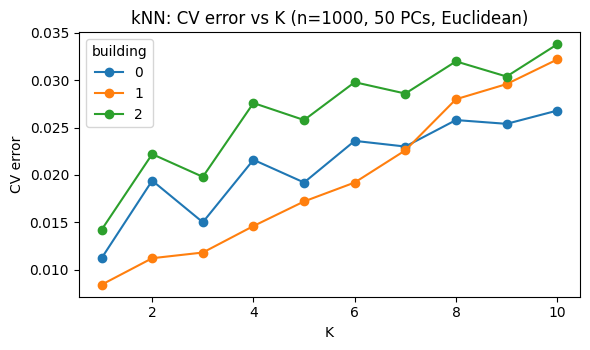

Best K per building: {0: 1, 1: 1, 2: 1}


building,0,1,2
k,,,
1,0.0112,0.0084,0.0142
2,0.0194,0.0112,0.0222
3,0.0150,0.0118,0.0198
4,0.0216,0.0146,0.0276
5,0.0192,0.0172,0.0258
6,0.0236,0.0192,0.0298
7,0.0230,0.0226,0.0286
8,0.0258,0.0280,0.0320
9,0.0254,0.0296,0.0304


In [4]:
KS = list(range(1, 11))
k_rows = []
for b, (X, y) in data.items():
    for r in range(N_ROUNDS):
        Xs, ys = subsample(X, y, 1000, SEED + r)
        for k, e in cv_knn_over_k(Xs, ys, KS, 50, SEED + r).items():
            k_rows.append(dict(building=b, k=k, round=r, cv_error=e))
k_res = pd.DataFrame(k_rows).groupby(["building", "k"]).cv_error.mean().unstack(0)

ax = k_res.plot(marker="o", figsize=(6, 3.6), title="kNN: CV error vs K (n=1000, 50 PCs, Euclidean)")
ax.set(xlabel="K", ylabel="CV error"); plt.tight_layout(); plt.show()
print("Best K per building:", k_res.idxmin().to_dict())
k_res.round(4)

### 3.2 Effect of PCA size and sample size (paper Fig. 3 and Sec. III.I)
We run **K=1** over every sample size, every PCA size (5/50/200), plus the raw features as a baseline, in both PCA modes. `n_samples` is the number of rows actually used: building 1 has fewer than 5,000 rows after cleaning, so its "5000" setting uses everything.

In [5]:
def run_grid(data, pca_mode, n_rounds=N_ROUNDS):
    rows = []
    for b, (X, y) in data.items():
        for n in SAMPLE_SIZES:
            per_round = []
            for r in range(n_rounds):
                Xs, ys = subsample(X, y, n, SEED + r)
                per_round.append(cv_knn(Xs, ys, PCA_SIZES, k=1, pca_mode=pca_mode, seed=SEED + r))
            for m in PCA_SIZES + ["raw"]:
                v = [d[m] for d in per_round]
                rows.append(dict(building=b, requested_n=n, n_samples=min(n, len(X)),
                                 features=m, mode=pca_mode, cv_error=np.mean(v), std=np.std(v)))
    return pd.DataFrame(rows)

t = time.time()
grid = pd.concat([run_grid(data, "fold"), run_grid(data, "global")], ignore_index=True)
print(f"grid done in {time.time() - t:.0f}s")
grid.head()

grid done in 53s


,building,requested_n,n_samples,features,mode,cv_error,std
0,0,100,100,5,fold,0.192,0.047497
1,0,100,100,50,fold,0.108,0.033106
2,0,100,100,200,fold,0.110,0.032863
3,0,100,100,raw,fold,0.110,0.032863
4,0,200,200,5,fold,0.151,0.039421


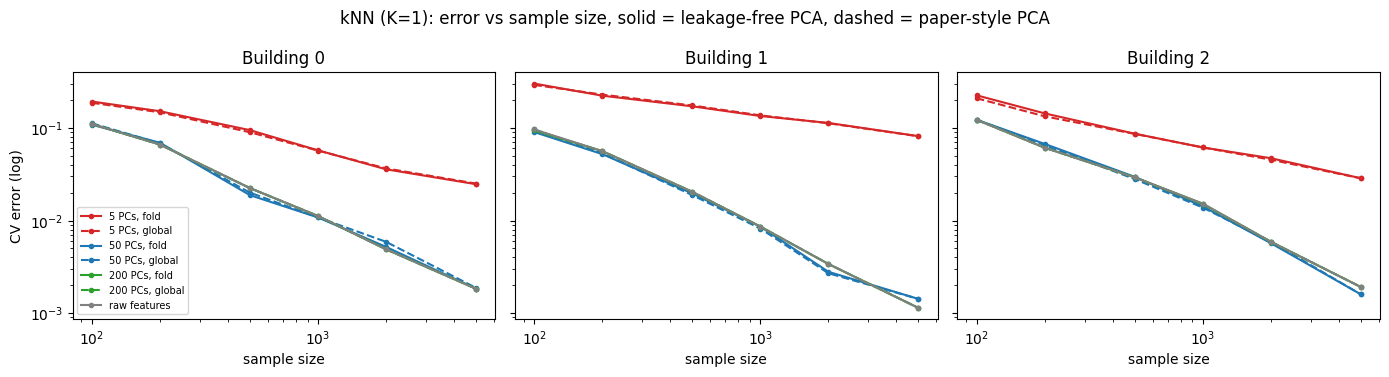

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
styles = {5: "tab:red", 50: "tab:blue", 200: "tab:green", "raw": "gray"}
for ax, b in zip(axes, data):
    for m, c in styles.items():
        for mode, ls in (("fold", "-"), ("global", "--")):
            s = grid[(grid.building == b) & (grid.features == m) & (grid["mode"] == mode)]
            if m == "raw" and mode == "global":   # raw has no PCA, so the modes coincide
                continue
            ax.plot(s.requested_n, s.cv_error, ls, color=c, marker="o", ms=3,
                    label=f"{m} PCs, {mode}" if m != "raw" else "raw features")
    ax.set(xscale="log", yscale="log", title=f"Building {b}", xlabel="sample size")
axes[0].set_ylabel("CV error (log)"); axes[0].legend(fontsize=7)
plt.suptitle("kNN (K=1): error vs sample size, solid = leakage-free PCA, dashed = paper-style PCA")
plt.tight_layout(); plt.show()

**Reading the plot:** the grey *raw features* line lies exactly on the *200 PCs* line. With about 200 features, 200 PCs is only a rotation, and rotations preserve Euclidean distances, so kNN gives identical answers. Real dimensionality reduction only happens at 5 and 50 PCs.

**Comparison with the paper's Fig. 3** (the paper does not say which building; ours are shown for all three):

In [7]:
paper = pd.DataFrame({"paper n=500": [0.1193, 0.034, 0.02], "paper n=5000": [0.0281, 0.0017, 0.0012]},
                     index=pd.Index(PCA_SIZES, name="features"))
sel = grid[grid.requested_n.isin([500, 5000]) & grid.features.isin(PCA_SIZES)]
ours = sel.pivot_table(index=["mode", "features"], columns=["requested_n", "building"], values="cv_error")
print("Paper (Fig. 3):"); display(paper)
print("Ours (K=1):");     display(ours.round(4))

Paper (Fig. 3):


,paper n=500,paper n=5000
features,,
5,0.1193,0.0281
50,0.0340,0.0017
200,0.0200,0.0012


Ours (K=1):


requested_n        500                     5000                
building              0       1       2       0       1       2
mode   features                                                
fold   5         0.0944  0.1704  0.0864  0.0246  0.0813  0.0286
       50        0.0188  0.0196  0.0296  0.0018  0.0014  0.0016
       200       0.0224  0.0204  0.0292  0.0018  0.0011  0.0019
global 5         0.0896  0.1740  0.0860  0.0250  0.0810  0.0285
       50        0.0200  0.0188  0.0280  0.0019  0.0014  0.0016
       200       0.0224  0.0204  0.0292  0.0018  0.0011  0.0019

## 4. Decision tree

The paper builds the tree in **R (`rpart`)** on the raw WAP features (its top variables are `V3, V4, V177, V179, V172`, i.e. `WAP003, WAP004, WAP177, WAP179, WAP172`), then:
1. grows a **full tree** with complexity parameter `cp = 0`;
2. prunes it with **(a)** the cp that minimises the cross-validation error and **(b)** the **one-standard-error (1-SE) rule**: the simplest tree whose CV error is within one SE of the minimum.

scikit-learn's equivalent of `cp` is **`ccp_alpha`** (cost-complexity pruning). The scales differ, but the mechanics are the same: a bigger alpha means a smaller tree. We use the full data of each building and 10-fold CV.

**Matching `rpart`'s defaults.** `rpart` will not split a node with fewer than 20 samples (`minsplit=20`) or create a leaf with fewer than 7 (`minbucket=7`). scikit-learn's defaults are 2 and 1, which grows a much bigger, more overfit tree. To replicate the paper we use `min_samples_split=20, min_samples_leaf=7` (set in `TREE_KW`). Section 4.2 also reports the sklearn-default error for comparison.

*Surrogate splits* (the paper's missing-value mechanism) are specific to `rpart` and not available in scikit-learn. Our data has no missing values after filling, so this doesn't affect the results.

In [8]:
TREE_KW = dict(min_samples_split=20, min_samples_leaf=7, random_state=0)   # rpart defaults

def tree_cv_curve(X, y, n_alphas=30, seed=SEED):
    Xv, yv = X.values.astype(float), y.values
    full = DecisionTreeClassifier(**TREE_KW).fit(Xv, yv)
    path = full.cost_complexity_pruning_path(Xv, yv).ccp_alphas
    alphas = path[np.unique(np.linspace(0, len(path) - 1, n_alphas).astype(int))]
    base_err = 1 - np.bincount(yv).max() / len(yv)            # root-node error (majority class)
    folds = list(KFold(N_FOLDS, shuffle=True, random_state=seed).split(Xv))
    rows = []
    for a in alphas:
        errs = []
        for tr, te in folds:
            t = DecisionTreeClassifier(ccp_alpha=a, **TREE_KW).fit(Xv[tr], yv[tr])
            errs.append((t.predict(Xv[te]) != yv[te]).mean())
        leaves = DecisionTreeClassifier(ccp_alpha=a, **TREE_KW).fit(Xv, yv).get_n_leaves()
        rows.append(dict(alpha=a, leaves=leaves, cv_error=np.mean(errs),
                         se=np.std(errs, ddof=1) / np.sqrt(N_FOLDS), rel_error=np.mean(errs) / base_err))
    return pd.DataFrame(rows), base_err

def pick_rules(curve):
    i_min = curve.cv_error.idxmin()
    thr   = curve.cv_error[i_min] + curve.se[i_min]
    i_1se = curve[curve.cv_error <= thr].alpha.idxmax()       # largest alpha within 1 SE
    return i_min, i_1se

curves = {}
t = time.time()
for b, (X, y) in data.items():
    curves[b] = tree_cv_curve(X, y)
print(f"tree CV curves done in {time.time() - t:.0f}s")

tree CV curves done in 104s


### 4.1 Pruning curves (paper Figs. 6 and 7)

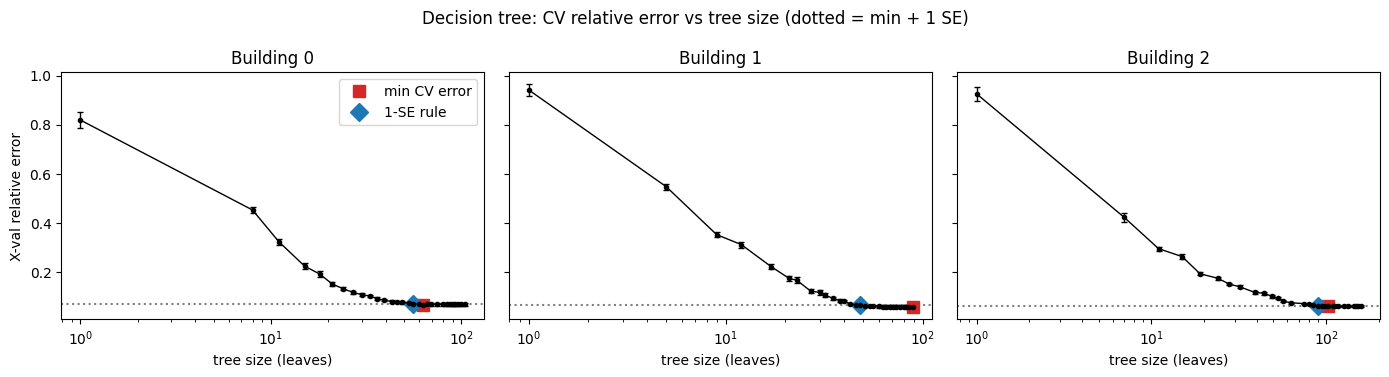

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, b in zip(axes, data):
    cv, base = curves[b]
    i_min, i_1se = pick_rules(cv)
    ax.errorbar(cv.leaves, cv.rel_error, yerr=cv.se / base, fmt="o-", ms=3, color="k", lw=1, capsize=2)
    ax.axhline((cv.cv_error[i_min] + cv.se[i_min]) / base, ls=":", color="gray")
    ax.plot(cv.leaves[i_min], cv.rel_error[i_min], "s", color="tab:red", ms=9, label="min CV error")
    ax.plot(cv.leaves[i_1se], cv.rel_error[i_1se], "D", color="tab:blue", ms=9, label="1-SE rule")
    ax.set(xscale="log", title=f"Building {b}", xlabel="tree size (leaves)")
axes[0].set_ylabel("X-val relative error"); axes[0].legend()
plt.suptitle("Decision tree: CV relative error vs tree size (dotted = min + 1 SE)")
plt.tight_layout(); plt.show()

### 4.2 Tree statistics (paper Fig. 8): full tree vs CV-pruned vs 1-SE-pruned

In [10]:
rows, tops = [], {}
for b, (X, y) in data.items():
    cv, base = curves[b]
    i_min, i_1se = pick_rules(cv)
    for name, alpha, cv_err in (("Full grown tree", 0.0, cv.cv_error.iloc[0]),
                                ("Pruned with CV (min)", cv.alpha[i_min], cv.cv_error[i_min]),
                                ("Pruned with 1-SE", cv.alpha[i_1se], cv.cv_error[i_1se])):
        t = DecisionTreeClassifier(ccp_alpha=alpha, **TREE_KW).fit(X.values.astype(float), y.values)
        top5 = pd.Series(t.feature_importances_, index=X.columns).nlargest(5).index.tolist()
        rows.append(dict(building=b, tree=name, depth=t.get_depth(), splits=t.get_n_leaves() - 1,
                         cv_error=round(cv_err, 4), top5_variables=" ".join(top5)))
        tops[(b, name)] = top5
tree_tbl = pd.DataFrame(rows)
display(tree_tbl)

paper_tree = pd.DataFrame([
    ("Full grown tree",      32, "-",   "V3 V4 V177 V179 V172"),
    ("Pruned with CV",       28, 0.078, "V3 V4 V177 V179 V172"),
    ("Pruned with 1-SE",     20, 0.071, "V3 V4 V177 V179 V172")],
    columns=["tree", "depth", "cv_error", "top5_variables"])
print("Paper (Fig. 8; building not stated):"); display(paper_tree)

# for reference: the same full tree with scikit-learn's own defaults (no min split/leaf size)
cv10 = KFold(N_FOLDS, shuffle=True, random_state=SEED)
ref = {}
for b, (X, y) in data.items():
    errs = []
    for tr, te in cv10.split(X):
        t = DecisionTreeClassifier(random_state=0).fit(X.values[tr].astype(float), y.values[tr])
        errs.append((t.predict(X.values[te].astype(float)) != y.values[te]).mean())
    ref[b] = round(np.mean(errs), 4)
print("Full tree CV error with scikit-learn defaults (min_samples_leaf=1):", ref)

,building,tree,depth,splits,cv_error,top5_variables
0,0,Full grown tree,29,103,0.0480,WAP075 WAP080 WAP043 WAP042 WAP040
1,0,Pruned with CV (min),19,62,0.0475,WAP075 WAP080 WAP043 WAP042 WAP040
2,0,Pruned with 1-SE,17,55,0.0500,WAP075 WAP080 WAP043 WAP042 WAP040
3,1,Full grown tree,31,88,0.0414,WAP140 WAP334 WAP126 WAP120 WAP125
4,1,Pruned with CV (min),31,88,0.0414,WAP140 WAP334 WAP126 WAP120 WAP125
5,1,Pruned with 1-SE,21,47,0.0447,WAP140 WAP334 WAP126 WAP120 WAP125
6,2,Full grown tree,40,157,0.0413,WAP096 WAP122 WAP131 WAP502 WAP118
7,2,Pruned with CV (min),26,102,0.0409,WAP096 WAP122 WAP131 WAP502 WAP118
8,2,Pruned with 1-SE,26,89,0.0427,WAP096 WAP122 WAP131 WAP502 WAP118


Paper (Fig. 8; building not stated):


,tree,depth,cv_error,top5_variables
0,Full grown tree,32,-,V3 V4 V177 V179 V172
1,Pruned with CV,28,0.078,V3 V4 V177 V179 V172
2,Pruned with 1-SE,20,0.071,V3 V4 V177 V179 V172


Full tree CV error with scikit-learn defaults (min_samples_leaf=1): {0: np.float64(0.0238), 1: np.float64(0.021), 2: np.float64(0.0246)}


**On the top-5 variables:** the paper lists `V3, V4, V177, V179, V172`. In this training file `WAP003` and `WAP004` are **never detected** in any building, so the paper's column numbering cannot map one-to-one onto ours (they likely used a differently indexed copy, a different subsample, or all buildings together). We therefore don't compare variable names; what should agree is the *pattern*: a handful of strong APs dominate the importance ranking.

## 5. Summary and reading the results

In [11]:
best = (grid[(grid.requested_n == 5000) & grid.features.isin(PCA_SIZES) & (grid["mode"] == "fold")]
        .sort_values("cv_error").groupby("building").first()[["features", "n_samples", "cv_error"]])
best.columns = ["kNN best #PCs", "rows used", "kNN CV error (K=1, n=5000)"]
tree_best = (tree_tbl[tree_tbl.tree == "Pruned with 1-SE"].set_index("building")[["depth", "cv_error"]]
             .rename(columns={"depth": "tree depth (1-SE)", "cv_error": "tree CV error (1-SE)"}))
summary = best.join(tree_best); summary

,kNN best #PCs,rows used,"kNN CV error (K=1, n=5000)",tree depth (1-SE),tree CV error (1-SE)
building,,,,,
0,50,5000,0.001840,17,0.0500
1,200,4904,0.001142,21,0.0447
2,50,5000,0.001600,26,0.0427


**What we observe**
- **K:** error rises with K and K=1 is best in all three buildings (matches the paper's Fig. 4).
- **Sample size / features:** error falls sharply with more data; 50 vs 200 PCs differ little, while 5 PCs is clearly worse (matches the paper). At n=5000 our error (about 0.001 to 0.002 for 50/200 PCs) is close to the paper's 0.0017/0.0012.
- **kNN vs tree:** kNN (about 0.002) is far better than a single pruned tree (about 0.04 to 0.05), supporting the paper's move to boosting.
- **Pruning:** the CV-min tree is smaller than the full tree in buildings 0 and 2 (building 1's CV-min coincides with the full tree on our coarse alpha grid), and the 1-SE tree is smaller still for about +0.002 to +0.003 extra error. This reproduces the paper's full > CV > 1-SE ordering of tree size (32 > 28 > 20).
- **Tree error:** ours (about 4 to 5%) is lower than the paper's 7 to 8%. The paper doesn't state the building or sample size behind Fig. 8, so a smaller or different sample may explain it.

**Next steps for the team:** the same `cv_knn`-style loop plugs in Gradient Boosting, SVM (polynomial kernel, degree 3) and your extra model (e.g. Random Forest or an MLP), using the identical subsampling, 10-fold CV and 5-round averaging.

## 6. Save results

In [12]:
os.makedirs(RESULTS_DIR, exist_ok=True)
grid.to_csv(os.path.join(RESULTS_DIR, "knn_grid.csv"), index=False)
k_res.to_csv(os.path.join(RESULTS_DIR, "knn_vs_k.csv"))
tree_tbl.to_csv(os.path.join(RESULTS_DIR, "tree_summary.csv"), index=False)
print("saved to", os.path.abspath(RESULTS_DIR), os.listdir(RESULTS_DIR))

saved to /tmp/run3/models/results ['tree_summary.csv', 'knn_vs_k.csv', 'knn_grid.csv']
